# Cyclic Peptide Permeability: Classical ML on 2D and 3D Molecular Features

Predicts the passive membrane permeability of cyclic peptides (log₁₀ P_app, cm/s) in [CycPeptMPDB](http://cycpeptmpdb.com) with seven regressors (Linear Regression, Ridge, Lasso, k-nearest neighbours, Random Forest, XGBoost and LightGBM) and compares these molecular representations:

| Representation | Description |
|---|---|
| ECFP4 | 2,048-bit Morgan fingerprint (radius 2) computed from SMILES |
| ECFP4 counts | Count-based version of ECFP4 |
| RDKit descriptors | 210 precomputed 2D descriptors (`MaxEStateIndex` … `PC2`) |
| E3FP | 2,048-bit 3D fingerprint of the lowest-energy conformer in water, chloroform and vacuum |
| Solvent statistics | Per-bit mean, standard deviation and chloroform/water difference of a peptide's three E3FPs, plus cosine distances between them ("chameleonicity") |

**Evaluation.** Every feature set is scored with shuffled 10-fold cross-validation (CV). Experiments 1 and 2 are also trained on an 80/20 split and scored on the held-out 20%. All models use library-default hyperparameters.

**Result.** Random Forest on ECFP4 counts, descriptors and E3FP solvent statistics reaches **CV R² = 0.431** (MAE 0.479) on the 7,451 peptides with conformers. The best model on ECFP4 alone reaches 0.337.

## Setup

In [ ]:
import logging
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from e3fp.pipeline import fprints_from_mol
from lightgbm import LGBMRegressor
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from xgboost import XGBRegressor

DATA_DIR = Path("../data")
SEED = 42
np.random.seed(SEED)

# e3fp sets the root logger to INFO and logs every molecule; show warnings and errors only
logging.getLogger().setLevel(logging.WARNING)
# LightGBM is fitted on NumPy arrays; silence scikit-learn's spurious feature-name warning
warnings.filterwarnings("ignore", message="X does not have valid feature names")

## 1. Data

`CycPeptMPDB_Peptide_All.csv` contains 8,466 cyclic peptides with SMILES, monomer sequences, precomputed RDKit descriptors and the permeability label `Permeability` (log₁₀ P_app in cm/s). See the [README](../README.md#getting-started) for download instructions.

In [2]:
cycdf = pd.read_csv(DATA_DIR / "CycPeptMPDB_Peptide_All.csv", low_memory=False)
cycdf = cycdf.dropna(subset=["SMILES", "Permeability"])
cycdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8466 entries, 0 to 8465
Columns: 247 entries, ID to H2O_3DPSA
dtypes: float64(115), int64(117), object(15)
memory usage: 16.0+ MB


### 1.1 ECFP4 fingerprints

2,048-bit Morgan fingerprints (radius 2) computed with RDKit from each peptide's SMILES.

In [ ]:
def generate_mfp(smiles, radius=2, n_bits=2048):
    """2,048-bit ECFP4 (Morgan, radius 2) fingerprint; all zeros if RDKit cannot parse the SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    return np.array(gen.GetFingerprint(mol))


cycdf["Morgan_FP"] = cycdf["SMILES"].apply(generate_mfp)

### 1.2 E3FP fingerprints of solvent-specific conformers

CycPeptMPDB publishes the lowest-energy conformer of each peptide in water, chloroform and vacuum, downloaded with `scripts/download_cycpeptmpdb_3d.py`. Each conformer is encoded as an [E3FP](https://doi.org/10.1021/acs.jmedchem.7b00696) 3D fingerprint folded to 2,048 bits. Generation takes roughly an hour per solvent, so the resulting dataframe is cached as a pickle and reloaded on later runs.

In [8]:
PICKLE_PATH = DATA_DIR / "cycdf_with_e3fp_and_ecfp.pkl"
E3FP_BITS = 2048
SOLVENT_DIRS = {
    "chloroform": DATA_DIR / "sdf_chloroform",
    "vacuum": DATA_DIR / "sdf_vacuum",
    "water": DATA_DIR / "sdf_water",
}


def extract_id(filename):
    """CycPeptMPDB ID from a conformer file name, e.g. 'id_0042_water.mol' -> 42."""
    match = re.search(r"id_(\d+)", filename, re.IGNORECASE)
    return int(match.group(1)) if match else None


if PICKLE_PATH.exists():
    print("pickle exists with e3fp and ecfp vectors, loading it...")
    cycdf = pd.read_pickle(PICKLE_PATH)
else:
    print("Pickle not found, generating E3FP fingerprints...")
    for solvent, folder in SOLVENT_DIRS.items():
        fp_map = {}
        mol_files = sorted(f for f in os.listdir(folder) if f.lower().endswith(".mol"))
        for fname in tqdm(mol_files, desc=f"{solvent:>10}", unit="mol"):
            mol_id = extract_id(fname)
            if mol_id is None:
                continue
            mol = Chem.MolFromMolFile(str(folder / fname), removeHs=False)
            if mol is None or mol.GetNumConformers() == 0:
                tqdm.write(f"WARNING: Could not read {fname}")
                continue
            try:
                # One conformer per file gives one fingerprint; fold it and convert to a 0/1 array
                fprints = fprints_from_mol(mol)
                if not fprints:
                    continue
                folded = fprints[-1].fold(E3FP_BITS)
                arr = np.zeros(E3FP_BITS, dtype=np.uint8)
                DataStructs.ConvertToNumpyArray(folded.to_rdkit(), arr)
                fp_map[mol_id] = arr
            except Exception as exc:
                tqdm.write(f"ERROR: {fname}: {exc}")

        col_name = f"{solvent}_E3FP"
        cycdf[col_name] = cycdf["ID"].astype(int).map(fp_map)  # NaN for peptides without a conformer
        missing = cycdf[col_name].isna().sum()
        tqdm.write(f"  ✓ {solvent}: {len(fp_map)} fingerprints added, {missing} rows unmatched\n")

    print("All three E3FP columns created!")
    cycdf.to_pickle(PICKLE_PATH)

Pickle not found, generating E3FP fingerprints...
  ✓ chloroform: 7451 fingerprints added, 1015 rows unmatched

  ✓ vacuum: 7451 fingerprints added, 1015 rows unmatched

  ✓ water: 7451 fingerprints added, 1015 rows unmatched

All three E3FP columns created!


Conformers are only available for IDs 1–7,451, so the experiments that use E3FP (sections 5 and 7) run on this 7,451-peptide subset.

In [ ]:
cycdf_e3fp = cycdf.dropna(subset=["water_E3FP", "chloroform_E3FP", "vacuum_E3FP"]).copy()

### 1.3 Target distribution

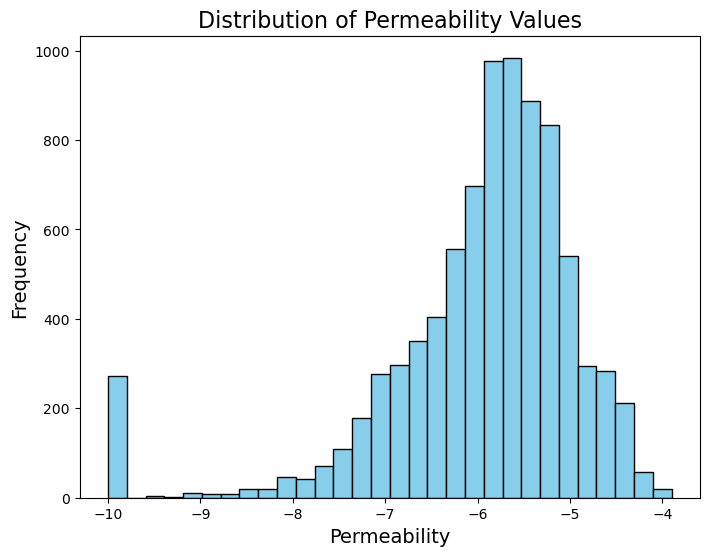

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(cycdf["Permeability"], bins=30, color='skyblue', edgecolor='black')
ax.set_title('Distribution of Permeability Values', fontsize=16)
ax.set_xlabel('Permeability', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
plt.show()

Permeability is centred near −6 with a long tail towards low values, plus a spike of 273 peptides at −10, the floor value for measurements below the detection limit. All models here treat these censored labels as exact values.

## 2. Models and evaluation

Seven regressors with library-default hyperparameters. `cv_evaluate_all` reports each model's mean MAE, MSE and R² over the same shuffled 10 folds; `holdout_evaluate_all` fits each model on a training split and scores it on the held-out test split.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=SEED),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=SEED),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=SEED, verbose=-1),
}

In [ ]:
CV = KFold(n_splits=10, shuffle=True, random_state=SEED)


def evaluate_model(model, X, y, cv=CV):
    """Cross-validate `model`; return its mean MAE, MSE and R² across folds."""
    scoring = ["neg_mean_absolute_error", "neg_mean_squared_error", "r2"]
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    mae = -scores["test_neg_mean_absolute_error"].mean()
    mse = -scores["test_neg_mean_squared_error"].mean()
    r2 = scores["test_r2"].mean()
    return mae, mse, r2


def cv_evaluate_all(X, y, evaluate=evaluate_model):
    """Cross-validate every model in `models`, printing one summary line per model."""
    results = {}
    for name, model in models.items():
        mae, mse, r2 = evaluate(model, X, y, CV)
        results[name] = {"CV_MAE": mae, "CV_MSE": mse, "CV_R2": r2}
        print(f"{name} CV: MAE={mae:.4f}, MSE={mse:.4f}, R2={r2:.4f}")
    return results


def holdout_evaluate_all(X_train, y_train, X_test, y_test, tag):
    """Fit every model on the training split; return a DataFrame of its test-set MAE, MSE and R²."""
    results = {}
    for name, model in models.items():
        y_pred = model.fit(X_train, y_train).predict(X_test)
        results[f"{name}+{tag}"] = {
            "Test_MAE": mean_absolute_error(y_test, y_pred),
            "Test_MSE": mean_squared_error(y_test, y_pred),
            "Test_R2": r2_score(y_test, y_pred),
        }
    return pd.DataFrame(results).T

## 3. Experiment 1: ECFP4

In [36]:
X = np.stack(cycdf["Morgan_FP"])  # (n_peptides, 2048) bit matrix
y = cycdf["Permeability"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (6772, 2048), Test shape: (1694, 2048)


In [ ]:
cv_ecfp = cv_evaluate_all(X, y)

Linear Regression CV: MAE=0.6359, MSE=0.9109, R2=0.2196
Ridge CV: MAE=0.6176, MSE=0.8370, R2=0.2825
Lasso CV: MAE=0.7542, MSE=1.1670, R2=-0.0015
Random Forest CV: MAE=0.6060, MSE=0.8744, R2=0.2501
KNN CV: MAE=0.6206, MSE=0.8768, R2=0.2477
XGBoost CV: MAE=0.5868, MSE=0.8106, R2=0.3050
LightGBM CV: MAE=0.5800, MSE=0.7737, R2=0.3371


In [56]:
test_df = holdout_evaluate_all(X_train, y_train, X_test, y_test, tag="ecfp")
test_df = test_df.sort_values(by="Test_R2", ascending=False).round(4)
print("ML MODELS: ECFP")
print(test_df)

ML MODELS: ECFP
                        Test_MAE  Test_MSE  Test_R2
LightGBM+ecfp             0.5934    0.8428   0.2956
Ridge+ecfp                0.6329    0.8908   0.2555
XGBoost+ecfp              0.6133    0.9005   0.2474
Random Forest+ecfp        0.6305    0.9577   0.1996
KNN+ecfp                  0.6439    0.9632   0.1950
Linear Regression+ecfp    0.6610    0.9849   0.1769
Lasso+ecfp                0.7618    1.1966  -0.0000


LightGBM is best in both CV (R² 0.337) and on the hold-out split (0.296). Lasso with the default α = 1 shrinks every coefficient to zero and predicts the mean (R² ≈ 0).

## 4. Experiment 2: ECFP4 + RDKit descriptors

The 210 descriptors are standardised and appended to the fingerprint, giving 2,258 features. The scaler is fit on all peptides before splitting, which leaks test-set means and variances into training. This does not affect the tree models, which are invariant to feature scaling; section 7 avoids it by scaling inside each CV fold.

In [ ]:
# 208 RDKit 2D descriptors + 2 precomputed principal components (columns MaxEStateIndex ... PC2)
descriptors = StandardScaler().fit_transform(cycdf.iloc[:, 35:245])

X2 = np.hstack([X, descriptors])
y2 = cycdf["Permeability"].values
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=SEED)

In [10]:
cv_ecfp_desc = cv_evaluate_all(X2, y2)

Linear Regression CV: MAE=610566.6152, MSE=70793282367823.2188, R2=-63909167322384.9844
Ridge CV: MAE=0.6077, MSE=0.8874, R2=0.2392
Lasso CV: MAE=0.7542, MSE=1.1670, R2=-0.0017
Random Forest CV: MAE=0.5939, MSE=0.8571, R2=0.2647
KNN CV: MAE=0.5946, MSE=0.8617, R2=0.2608
XGBoost CV: MAE=0.5823, MSE=0.8443, R2=0.2761
LightGBM CV: MAE=0.5533, MSE=0.7501, R2=0.3571


In [61]:
test_dfa = holdout_evaluate_all(X_train2, y_train2, X_test2, y_test2, tag="ecfp+struc")
test_dfa = test_dfa.sort_values(by="Test_R2", ascending=False).round(4)
print("ML MODELS: ECFP + PROPERTIES")
print(test_dfa)

ML MODELS: ECFP + PROPERTIES
                                 Test_MAE      Test_MSE       Test_R2
LightGBM+ecfp+struc                0.5724  8.197000e-01  3.149000e-01
Ridge+ecfp+struc                   0.6217  8.798000e-01  2.647000e-01
KNN+ecfp+struc                     0.6141  9.027000e-01  2.456000e-01
XGBoost+ecfp+struc                 0.5994  9.074000e-01  2.417000e-01
Random Forest+ecfp+struc           0.6087  9.262000e-01  2.259000e-01
Lasso+ecfp+struc                   0.7618  1.196600e+00 -0.000000e+00
Linear Regression+ecfp+struc  819325.6101  9.567116e+13 -7.995804e+13


Descriptors improve LightGBM from R² 0.296 to 0.315 on the hold-out split (CV: 0.337 → 0.357). Ordinary least squares breaks down (R² ≪ 0) because the 2,258 partly collinear features make the problem ill-conditioned; Ridge's L2 penalty keeps it stable.

### 4.1 Feature selection with recursive feature elimination (RFE)

RFE repeatedly drops the 10% least important features, as ranked by a random forest, until the target number remains. The selector is fit on the training split only, and each subset is scored by a 150-tree random forest on the held-out split.


Running RFE → keeping 2000 features...
→ 2000 features → Test R² = 0.2292  RMSE = 0.9603

Running RFE → keeping 1500 features...
→ 1500 features → Test R² = 0.2287  RMSE = 0.9607

Running RFE → keeping 1000 features...
→ 1000 features → Test R² = 0.2299  RMSE = 0.9599

Running RFE → keeping 600 features...
→ 600 features → Test R² = 0.2291  RMSE = 0.9604

Running RFE → keeping 400 features...
→ 400 features → Test R² = 0.2304  RMSE = 0.9596

Running RFE → keeping 300 features...
→ 300 features → Test R² = 0.2305  RMSE = 0.9596

Running RFE → keeping 200 features...
→ 200 features → Test R² = 0.2301  RMSE = 0.9598

Running RFE → keeping 100 features...
→ 100 features → Test R² = 0.2257  RMSE = 0.9625

Running RFE → keeping 50 features...
→  50 features → Test R² = 0.2181  RMSE = 0.9672


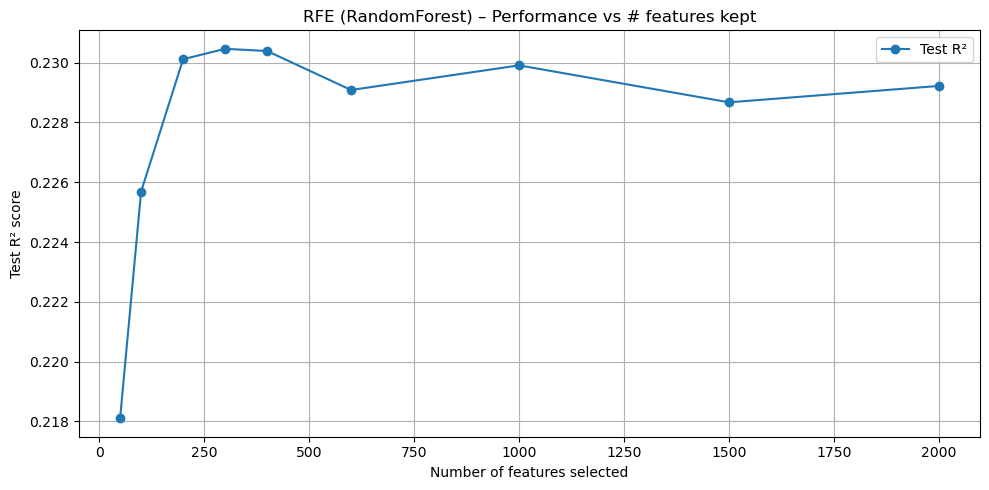

In [43]:
def make_rfe(n_features):
    """RFE ranked by random-forest impurity importance, dropping 10% of the remaining features per step."""
    selector = RandomForestRegressor(n_estimators=120, max_depth=10, max_features='sqrt',
                                     random_state=SEED, n_jobs=-1)
    return RFE(estimator=selector, n_features_to_select=n_features, step=0.10)


n_features_to_select = [2000, 1500, 1000, 600, 400, 300, 200, 100, 50]
r2_scores = []

for n in n_features_to_select:
    print(f"\nRunning RFE → keeping {n} features...")
    rfe = make_rfe(n).fit(X_train2, y_train2)
    X_train_rfe = rfe.transform(X_train2)
    X_test_rfe = rfe.transform(X_test2)

    rf_final = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
    rf_final.fit(X_train_rfe, y_train2)
    y_pred = rf_final.predict(X_test_rfe)

    r2 = r2_score(y_test2, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test2, y_pred))
    r2_scores.append(r2)
    print(f"→ {n:3d} features → Test R² = {r2:.4f}  RMSE = {rmse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_features_to_select, r2_scores, 'o-', label='Test R²')
plt.xlabel('Number of features selected')
plt.ylabel('Test R² score')
plt.title('RFE (RandomForest) – Performance vs # features kept')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Test R² is flat (0.229–0.231) from 200 to 2,000 features and drops off below 200, so a 600-feature subset from the plateau is used below. Because the subset size is read off the test split, treat this curve as exploratory.

In [12]:
best_n_features = 600

rfe_final = make_rfe(best_n_features).fit(X_train2, y_train2)  # fit on the training split only
support = rfe_final.support_  # boolean mask of the selected columns
print(f"Number of selected features: {support.sum()}")

X_train_selected = X_train2[:, support]
X_test_selected = X_test2[:, support]
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected  shape: {X_test_selected.shape}")

Number of selected features: 600
X_train_selected shape: (6772, 600)
X_test_selected  shape: (1694, 600)


In [16]:
# Optimistic: the RFE mask was fit on the training split, which overlaps every CV fold
cv_ecfp_desc_rfe = cv_evaluate_all(X2[:, support], y2)

Linear Regression CV: MAE=419390.5434, MSE=50941896221677.0078, R2=-43110945226331.3281
Ridge CV: MAE=0.6061, MSE=0.8515, R2=0.2711
Lasso CV: MAE=0.7542, MSE=1.1670, R2=-0.0017
Random Forest CV: MAE=0.5936, MSE=0.8576, R2=0.2644
KNN CV: MAE=0.5918, MSE=0.8597, R2=0.2624
XGBoost CV: MAE=0.5874, MSE=0.8642, R2=0.2586
LightGBM CV: MAE=0.5529, MSE=0.7449, R2=0.3619


In [64]:
test_df2 = holdout_evaluate_all(X_train_selected, y_train2, X_test_selected, y_test2,
                                tag="ecfp+struc+feature_sel").round(4)
print("ML MODELS: ECFP + PROPERTIES + FEATURE SELECTION")
print(test_df2)

ML MODELS: ECFP + PROPERTIES + FEATURE SELECTION
                                             Test_MAE      Test_MSE  \
Linear Regression+ecfp+struc+feature_sel  451455.6810  4.368935e+13   
Ridge+ecfp+struc+feature_sel                   0.6222  8.777000e-01   
Lasso+ecfp+struc+feature_sel                   0.7618  1.196600e+00   
Random Forest+ecfp+struc+feature_sel           0.6088  9.249000e-01   
KNN+ecfp+struc+feature_sel                     0.6144  9.186000e-01   
XGBoost+ecfp+struc+feature_sel                 0.6096  9.425000e-01   
LightGBM+ecfp+struc+feature_sel                0.5737  8.251000e-01   

                                               Test_R2  
Linear Regression+ecfp+struc+feature_sel -3.651377e+13  
Ridge+ecfp+struc+feature_sel              2.664000e-01  
Lasso+ecfp+struc+feature_sel             -0.000000e+00  
Random Forest+ecfp+struc+feature_sel      2.270000e-01  
KNN+ecfp+struc+feature_sel                2.323000e-01  
XGBoost+ecfp+struc+feature_sel          

On the hold-out split, the 600 selected features perform on par with all 2,258 (LightGBM R² 0.310 vs 0.315), so the models already cope with the redundant features.

### 4.2 Dimensionality reduction with PCA

The same features are projected onto the principal components that explain 95% of the training-set variance. The descriptors are already standardised and the fingerprint bits are binary, so no further scaling is applied.

Cumulative explained variance:
  1 components: 0.3440
  2 components: 0.4542
  3 components: 0.4983
  4 components: 0.5339
  5 components: 0.5660
  6 components: 0.5919
  7 components: 0.6160
  8 components: 0.6399
  9 components: 0.6603
 10 components: 0.6789
 11 components: 0.6958
 12 components: 0.7115
 13 components: 0.7243
 14 components: 0.7361
 15 components: 0.7471
 16 components: 0.7579
 17 components: 0.7670
 18 components: 0.7758
 19 components: 0.7844
 20 components: 0.7926


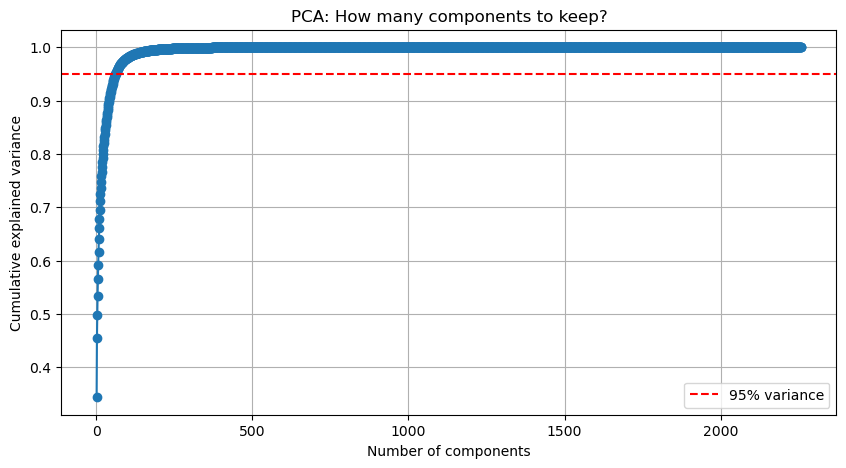

Choosing 62 components for ~95% variance
Original dims: 2258 → Reduced: 62


In [45]:
pca = PCA().fit(X_train2)  # fit on the training split only
cum_var = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative explained variance:")
for i, var in enumerate(cum_var[:20], 1):
    print(f"{i:3d} components: {var:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, 'o-')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: How many components to keep?')
plt.grid(True)
plt.legend()
plt.show()

n_components = np.argmax(cum_var >= 0.95) + 1  # smallest number of components reaching 95%
print(f"Choosing {n_components} components for ~95% variance")

pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train2)
X_test_pca = pca_final.transform(X_test2)
print(f"Original dims: {X_train2.shape[1]} → Reduced: {X_train_pca.shape[1]}")

In [50]:
# Optimistic: PCA is refit on the full dataset, so every CV fold shares the projection
cv_ecfp_desc_pca = cv_evaluate_all(pca_final.fit_transform(X2), y2)

Linear Regression CV: MAE=0.6893, MSE=4.3368, R2=-2.4502
Ridge CV: MAE=0.6848, MSE=3.0656, R2=-1.4666
Lasso CV: MAE=0.7542, MSE=1.1670, R2=-0.0017
Random Forest CV: MAE=0.6125, MSE=0.8874, R2=0.2380
KNN CV: MAE=0.6005, MSE=0.8657, R2=0.2568
XGBoost CV: MAE=0.6260, MSE=0.9574, R2=0.1782
LightGBM CV: MAE=0.5752, MSE=0.7883, R2=0.3240


In [67]:
test_df3 = holdout_evaluate_all(X_train_pca, y_train2, X_test_pca, y_test2, tag="ecfp+struc+dim_red").round(4)
print("ML MODELS: ECFP + PROPERTIES + DIM. REDUCTION")
print(test_df3)

ML MODELS: ECFP + PROPERTIES + DIM. REDUCTION
                                      Test_MAE  Test_MSE  Test_R2
Linear Regression+ecfp+struc+dim_red    0.6668    0.9755   0.1848
Ridge+ecfp+struc+dim_red                0.6668    0.9755   0.1848
Lasso+ecfp+struc+dim_red                0.7618    1.1966  -0.0000
Random Forest+ecfp+struc+dim_red        0.6236    0.9324   0.2208
KNN+ecfp+struc+dim_red                  0.6105    0.8897   0.2564
XGBoost+ecfp+struc+dim_red              0.6385    1.0086   0.1570
LightGBM+ecfp+struc+dim_red             0.5916    0.8458   0.2931


62 components keep 95% of the variance, but the tree ensembles lose accuracy (LightGBM hold-out R² 0.293 vs 0.315; XGBoost 0.157 vs 0.242). High-variance directions in feature space are not necessarily the ones that predict permeability. KNN improves slightly in the lower-dimensional space (0.256 vs 0.246).

## 5. Experiment 3: E3FP 3D fingerprints

Water and chloroform E3FPs concatenated (4,096 bits) for the 7,451 peptides with conformers, scored with CV only.

In [33]:
X_water = np.stack(cycdf_e3fp["water_E3FP"].values)
X_chcl3 = np.stack(cycdf_e3fp["chloroform_E3FP"].values)
X_E3FP = np.hstack([X_water, X_chcl3])
y_E3FP = cycdf_e3fp["Permeability"].values

print(f"Water matrix shape: {X_water.shape}")
print(f"Chloroform matrix shape: {X_chcl3.shape}")
print(f"Combined feature matrix (X_E3FP) shape: {X_E3FP.shape}")
print(f"Target vector (y_E3FP) shape: {y_E3FP.shape}")

Water matrix shape: (7451, 2048)
Chloroform matrix shape: (7451, 2048)
Combined feature matrix (X_E3FP) shape: (7451, 4096)
Target vector (y_E3FP) shape: (7451,)


In [34]:
cv_e3fp = cv_evaluate_all(X_E3FP, y_E3FP)

Linear Regression CV: MAE=1.1718, MSE=2.3177, R2=-1.0511
Ridge CV: MAE=1.1533, MSE=2.2522, R2=-0.9930
Lasso CV: MAE=0.7164, MSE=1.1368, R2=-0.0004
Random Forest CV: MAE=0.6183, MSE=0.8958, R2=0.2107
KNN CV: MAE=0.8743, MSE=1.5049, R2=-0.3270
XGBoost CV: MAE=0.6583, MSE=0.9749, R2=0.1404
LightGBM CV: MAE=0.6210, MSE=0.8868, R2=0.2184


On their own, 3D fingerprints are weaker than ECFP4 (best CV R² 0.218 vs 0.337), so section 7 uses them alongside the 2D features rather than as a replacement.

## 6. Experiment 4: ECFP4 count fingerprints

Counts how often each hashed substructure occurs rather than only whether it occurs.

In [ ]:
def generate_mfp_counts(smiles, radius=2, n_bits=2048):
    """2,048-dimensional ECFP4 count vector; all zeros if RDKit cannot parse the SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.int32)
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    arr = np.zeros(n_bits, dtype=np.int32)
    DataStructs.ConvertToNumpyArray(gen.GetCountFingerprint(mol), arr)
    return arr


cycdf["Morgan_FP_Counts"] = cycdf["SMILES"].apply(generate_mfp_counts)

In [ ]:
X_ecfpc = np.stack(cycdf["Morgan_FP_Counts"])
cv_ecfp_counts = cv_evaluate_all(X_ecfpc, y)

Linear Regression CV: MAE=0.6280, MSE=0.8888, R2=0.2374
Ridge CV: MAE=0.6223, MSE=0.8684, R2=0.2551
Lasso CV: MAE=0.7542, MSE=1.1670, R2=-0.0017
Random Forest CV: MAE=0.5993, MSE=0.8695, R2=0.2542
KNN CV: MAE=0.6090, MSE=0.8604, R2=0.2614
XGBoost CV: MAE=0.5753, MSE=0.7974, R2=0.3169
LightGBM CV: MAE=0.5645, MSE=0.7552, R2=0.3530


Counts help the boosted models (LightGBM CV R² 0.353 vs 0.337 with bits; XGBoost 0.317 vs 0.305).

## 7. Experiment 5: ECFP4 counts + descriptors + 3D solvent features

Permeable cyclic peptides are often *chameleonic*: they expose polar groups in water but bury them, for example through intramolecular hydrogen bonds, in the low-dielectric membrane interior. To capture how each peptide's conformation responds to its environment, its three solvent-specific E3FPs are summarised as:

- the per-bit mean and standard deviation across water, chloroform and vacuum (2 × 2,048 features);
- the bits that differ between the chloroform and water conformers (2,048 features);
- three **chameleonicity scores**: the cosine distances between the water–chloroform, water–vacuum and chloroform–vacuum fingerprints.

Together with ECFP4 counts and the 210 descriptors, this gives 8,405 features for 7,451 peptides. Features are standardised inside each CV fold (`evaluate_model_scaled`), so there is no preprocessing leakage.

In [ ]:
def evaluate_model_scaled(model, X, y, cv=CV):
    """Like `evaluate_model`, but standardises features inside each CV fold (no scaling leakage)."""
    pipe = Pipeline([("scaler", StandardScaler()), ("regressor", model)])
    scoring = ["neg_mean_absolute_error", "neg_mean_squared_error", "r2"]
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    mae = -scores["test_neg_mean_absolute_error"].mean()
    mse = -scores["test_neg_mean_squared_error"].mean()
    r2 = scores["test_r2"].mean()
    return mae, mse, r2

In [ ]:
# Raw descriptors; evaluate_model_scaled standardises them per fold
descriptors_e3fp = cycdf_e3fp.iloc[:, 35:245].values

cycdf_e3fp["Morgan_FP_Counts"] = cycdf_e3fp["SMILES"].apply(generate_mfp_counts)
X_mfp_counts = np.stack(cycdf_e3fp["Morgan_FP_Counts"].values)

# Solvent fingerprints as a float array of shape (3 solvents, n_peptides, 2048 bits).
# Casting from uint8 matters: uint8 subtraction wraps around and scipy's cosine overflows on uint8 input.
X_vacuum = np.stack(cycdf_e3fp["vacuum_E3FP"].values)
X_e3fp_tensor = np.stack([X_water, X_chcl3, X_vacuum]).astype(np.float64)

# Per-bit summaries across solvents
mean_e3fp = X_e3fp_tensor.mean(axis=0)
std_e3fp = X_e3fp_tensor.std(axis=0)
diff_chcl3_water = np.abs(X_e3fp_tensor[1] - X_e3fp_tensor[0])

# Chameleonicity: cosine distance (1 - cosine similarity) between each pair of solvent fingerprints.
# Larger values mean the peptide's 3D environment changes more between solvents.
chame_scores = []
for i in range(X_e3fp_tensor.shape[1]):
    water, chcl3, vacuum = X_e3fp_tensor[:, i]
    chame_scores.append([
        cosine(water, chcl3) if np.any(water) and np.any(chcl3) else 0.0,
        cosine(water, vacuum) if np.any(water) and np.any(vacuum) else 0.0,
        cosine(chcl3, vacuum) if np.any(chcl3) and np.any(vacuum) else 0.0,
    ])
chame_scores = np.array(chame_scores)

X_combined = np.hstack([X_mfp_counts, descriptors_e3fp, mean_e3fp, std_e3fp, diff_chcl3_water, chame_scores])
y_combined = cycdf_e3fp["Permeability"].values

In [ ]:
cv_combined = cv_evaluate_all(X_combined, y_combined, evaluate=evaluate_model_scaled)

XGBoost CV: MAE=0.5233, MSE=0.7132, R2=0.3710
LightGBM CV: MAE=0.4950, MSE=0.6626, R2=0.4157
Linear Regression CV: MAE=41934340961.3864, MSE=13099920453014433648607232.0000, R2=-10862521872701315153395712.0000
Ridge CV: MAE=3471742932.9196, MSE=89794842342270563254272.0000, R2=-74458348239209260646400.0000
Lasso CV: MAE=0.7164, MSE=1.1368, R2=-0.0004
Random Forest CV: MAE=0.4793, MSE=0.6448, R2=0.4313
KNN CV: MAE=0.7755, MSE=1.1731, R2=-0.0325


Random Forest reaches **CV R² = 0.431 (MAE 0.479)**, the best result in this project, ahead of LightGBM (0.416) and XGBoost (0.371). OLS and Ridge (α = 1) are numerically unstable with more features than training samples per fold, and KNN degrades in the 8,405-dimensional space. This experiment uses the conformer subset and has no separate hold-out evaluation.

> **Note on the stored output.** The results above come from the original run, which computed the solvent features on `uint8` arrays. Two features were affected. SciPy's `cosine` overflows on `uint8` input and returned 0 for every peptide checked, so the three chameleonicity scores were constant and carried no information. The chloroform − water difference also wrapped around to 255 for bits lost in chloroform. The cell above now casts to float first. The reported R² therefore reflects the ECFP4 counts, descriptors and per-bit E3FP statistics. Re-running this section will show what the chameleonicity scores add.

## 8. Summary of hold-out results

Hold-out (20%) metrics for experiments 1 and 2, sorted by R².

In [70]:
combined_df = pd.concat([test_df, test_dfa, test_df2, test_df3])
combined_df = combined_df.sort_values(by="Test_R2", ascending=False)[["Test_R2", "Test_MSE", "Test_MAE"]]
combined_df

,Test_R2,Test_MSE,Test_MAE
LightGBM+ecfp+struc,3.149000e-01,8.197000e-01,0.5724
LightGBM+ecfp+struc+feature_sel,3.104000e-01,8.251000e-01,0.5737
LightGBM+ecfp,2.956000e-01,8.428000e-01,0.5934
LightGBM+ecfp+struc+dim_red,2.931000e-01,8.458000e-01,0.5916
Ridge+ecfp+struc+feature_sel,2.664000e-01,8.777000e-01,0.6222
Ridge+ecfp+struc,2.647000e-01,8.798000e-01,0.6217
KNN+ecfp+struc+dim_red,2.564000e-01,8.897000e-01,0.6105
Ridge+ecfp,2.555000e-01,8.908000e-01,0.6329
XGBoost+ecfp,2.474000e-01,9.005000e-01,0.6133
KNN+ecfp+struc,2.456000e-01,9.027000e-01,0.6141


**Takeaways**

- LightGBM is the strongest model on every 2D feature set; Random Forest edges ahead on the combined 2D + 3D features.
- Descriptors add a small, consistent gain over fingerprints alone. Neither RFE nor PCA improves on using all features.
- Combining count fingerprints and descriptors with per-bit statistics of the solvent-specific E3FPs gives the best CV score (R² 0.431), although on the conformer subset and without a hold-out test.
- Absolute performance is modest (R² ≈ 0.3–0.4). Likely causes are measurement noise across the literature sources pooled in CycPeptMPDB, the censored labels at −10 and untuned hyperparameters.

**Caveat.** 912 entries share their structure with at least one other entry in the database, so random splits can put the same peptide in both train and test. All scores are therefore likely to be optimistic, and a scaffold- or cluster-based split would be a stricter test.